# 🎓 Yonsei Colab Studio — 교육용 소형 LLM 파인튜닝

Google Colab **무료 T4 GPU**에서 [Unsloth](https://github.com/unslothai/unsloth)로 소형 LLM을 파인튜닝합니다.
메모리 사용량 ~80% 절감, 속도 2~3배로 무료 코랩에서도 OOM 없이 학습됩니다.

- **목적**: 20가지 교육 시나리오(소크라테스 문답 · 단계별 채점 · 학부모 안내문 변환 등) 특화
- **기본 모델**: `unsloth/Qwen2.5-1.5B-Instruct` (한국어 우수, 초경량)
- **방식**: LoRA(QLoRA) 4bit

> ⚠️ 먼저 상단 메뉴에서 **런타임 → 런타임 유형 변경 → T4 GPU** 를 선택하세요.


## 0. GPU 확인


In [39]:
!nvidia-smi


Sat Jun 20 14:39:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P0             28W /   70W |    9661MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Unsloth 설치
코랩 최신 환경에 맞춰 자동 설치됩니다. (1~2분 소요)


In [40]:
%%capture
import os
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps trl peft accelerate bitsandbytes
!pip install -q datasets


## 2. 학습 데이터 — HuggingFace Hub에서 받기
손으로 만든 예시가 아니라 **실제 한국어 교육 데이터셋**을 HF Hub에서 받아 20시나리오 포맷으로 변환합니다.

추천 데이터셋(소스별 N개만 streaming 추출 → 대형도 전체 다운로드 없음):
- `JosephLee/korean-socratic-qa` (105k) — 소크라테스 문답
- `kuotient/orca-math-word-problems-193k-korean` (193k) — 수학 단계 풀이
- `beomi/KoAlpaca-v1.1a` (21k) — 일반 instruction 베이스
- `jojo0217/korean_safe_conversation` (27k, Apache-2.0) — 정서지원·공감
- `neuralfoundry-coder/aihub-korean-education-instruct-sample` (6k) — 교육 상담·분석


In [41]:
# 저장소 clone (스크립트/레지스트리 사용)
REPO = 'https://github.com/xide-projext/xideproject.git'
import os
if not os.path.exists('xideproject'):
    !git clone -q $REPO
%cd xideproject

# HF에서 소스별 8000개씩 받아 data/hf_train.jsonl 생성 (≈5분)
!python scripts/fetch_hf_datasets.py --only code debug_en --per-source 5000 --val-ratio 0.05

from pathlib import Path
DATA_PATH = "data/hf_train.jsonl"
assert Path(DATA_PATH).exists(), "fetch 실패 — 위 셀 로그 확인"
print("학습 데이터 준비 완료:", DATA_PATH)


/content/xideproject/xideproject/xideproject

▶ [code] m-a-p/CodeFeedback-Filtered-Instruction (목표 5000개, license=Apache-2.0)
  ✅ 5000개 수집

▶ [debug_en] taisazero/socratic-debugging-benchmark (목표 5000개, license=MIT)
  ✅ 815개 수집

총 5815개 수집 → 분할 저장
  저장: data/hf_train.jsonl (5525개)
  저장: data/hf_val.jsonl (290개)

[소스별 분포]
  m-a-p/CodeFeedback-Filtered-Instruction                 5000
  taisazero/socratic-debugging-benchmark                  815

✅ 완료 — 학습엔 data/hf_train.jsonl 를 사용하세요 (seed_train.jsonl 은 예시 참고용)
학습 데이터 준비 완료: data/hf_train.jsonl


## 3. 모델 로드 (4bit)


In [42]:
from unsloth import FastLanguageModel
import torch

MAX_SEQ_LENGTH = 2048
MODEL_NAME = "unsloth/Qwen2.5-1.5B-Instruct"  # 더 작게: Qwen2.5-0.5B-Instruct / 다른 계열: Llama-3.2-1B-Instruct

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,            # 자동 감지 (T4=float16)
    load_in_4bit = True,
)


==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.36k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


## 4. LoRA 어댑터 추가
전체 가중치가 아닌 일부 행렬만 학습해 메모리/시간을 절약합니다.


In [43]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)


## 5. 데이터 포맷팅 (채팅 템플릿)
`instruction`(시나리오 지시) → system, `input` → user, `output` → assistant 로 매핑합니다.


In [44]:
from datasets import load_dataset
from unsloth.chat_templates import get_chat_template

tokenizer = get_chat_template(tokenizer, chat_template="qwen-2.5")

def to_text(ex):
    # 기존 ex["instruction"] 대신 무조건 시나리오[8]로 고정하여 학습시킵니다.
    fixed_instruction = (
        "시나리오[8]: 코딩 디버깅 가이드(힌트 제공형). "
        "당신은 친절한 프로그래밍 대화형 도우미입니다. "
        "정답 코드를 통째로 주기보다는, 학생이 버그의 원인을 깨닫고 스스로 해결할 수 있도록 한국어로 명확한 힌트와 원인 분석만 제공하세요."
    )

    msgs = [
        {"role": "system", "content": fixed_instruction},
        {"role": "user", "content": ex["input"]},
        {"role": "assistant", "content": ex["output"]},
    ]
    return {"text": tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)}

dataset = load_dataset("json", data_files=DATA_PATH, split="train")
dataset = dataset.map(to_text)
print("샘플 수:", len(dataset))
print(dataset[0]["text"][:600])


Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/5525 [00:00<?, ? examples/s]

샘플 수: 5525
<|im_start|>system
시나리오[8]: 코딩 디버깅 가이드(힌트 제공형). 당신은 친절한 프로그래밍 대화형 도우미입니다. 정답 코드를 통째로 주기보다는, 학생이 버그의 원인을 깨닫고 스스로 해결할 수 있도록 한국어로 명확한 힌트와 원인 분석만 제공하세요.<|im_end|>
<|im_start|>user
Given an array of positive and negative integers, replace all the negative numbers with zero and sort the array in descending order using Ruby. Ensure that the array has at least 10 elements and no more than 100 elements. Additionally, the array should not contain any duplicates. Finally, implement a binary search algorithm to find the index of a specific number in the sorted array.<|im_end|>
<|im_start|>assistant
Here i


## 6. 트레이너 설정 & 학습
데모용 `max_steps=60`. 실제 학습에선 `num_train_epochs`로 바꾸세요.


In [45]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    args = SFTConfig(
        dataset_text_field = "text",
        max_seq_length = MAX_SEQ_LENGTH,
        per_device_train_batch_size = 4, # Increased
        gradient_accumulation_steps = 2, # Decreased
        warmup_steps = 10,

        # --- [변경 구간] 데모용 max_steps는 주석처리하고 정식 에폭 학습으로 전환합니다 ---
        #max_steps = 150,
        num_train_epochs = 1,

        learning_rate = 2e-4,
        logging_steps = 5,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
    ),
)
trainer_stats = trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=3):   0%|          | 0/5525 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,525 | Num Epochs = 1 | Total steps = 691
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Step,Training Loss
5,1.098470
10,0.940567
15,0.799182
20,0.581569
25,0.501966
30,0.430454
35,0.524332
40,0.442121
45,0.521374
50,0.491718


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-691/tokenizer_config.json.


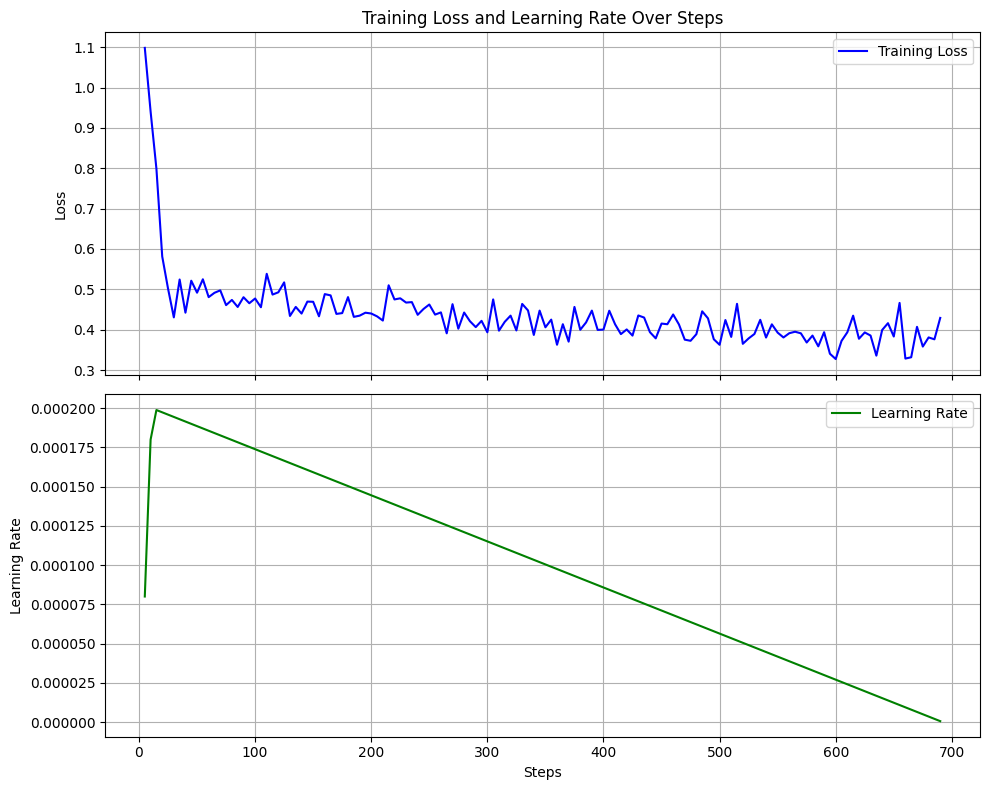

In [49]:
import matplotlib.pyplot as plt

# Extract training loss from trainer_stats
# trainer_stats 객체에는 logging_history 속성이 없으므로, trainer.state.log_history를 사용합니다.
log_history = trainer.state.log_history
training_loss = [entry['loss'] for entry in log_history if 'loss' in entry]
learning_rate = [entry['learning_rate'] for entry in log_history if 'learning_rate' in entry]
steps = [entry['step'] for entry in log_history if 'loss' in entry]

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot Training Loss
ax1.plot(steps, training_loss, label='Training Loss', color='blue')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss and Learning Rate Over Steps')
ax1.legend()
ax1.grid(True)

# Plot Learning Rate
ax2.plot(steps, learning_rate, label='Learning Rate', color='green')
ax2.set_xlabel('Steps')
ax2.set_ylabel('Learning Rate')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 7. 추론 테스트
학습한 시나리오 톤이 나오는지 즉석에서 확인합니다.


In [56]:
FastLanguageModel.for_inference(model)

messages = [
    {"role": "system", "content": "시나리오[8]: 코딩 디버깅 가이드(힌트 제공형). 당신은 친절한 프로그래밍 대화형 도우미입니다. 정답 코드를 통째로 주기보다는, 학생이 버그의 원인을 깨닫고 스스로 해결할 수 있도록 한국어로 명확한 힌트와 원인 분석만 제공하세요."},
    {"role": "user",
    "content": (
      "I wrote a Python function to calculate the sum of numbers from 1 to N, but the result is always smaller than expected. What's the problem? Please give me a hint.\n\n"
      "```python\n"
      "def sum_up_to_n(n):\n"
      "    total = 0\n"
      "    for i in range(n): # Loop from 0 to n-1\n"
      "        total += i\n"
      "    return total\n\n"
      "print(sum_up_to_n(5)) # Expected output: 15 (1+2+3+4+5), Actual output: 10 (0+1+2+3+4)\n"
      "```"
        )
     },
]
inputs = tokenizer.apply_chat_template(
    messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
).to("cuda")

out = model.generate(input_ids=inputs, max_new_tokens=256, temperature=0.7, do_sample=True)
print(tokenizer.decode(out[0], skip_special_tokens=True))

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


system
시나리오[8]: 코딩 디버깅 가이드(힌트 제공형). 당신은 친절한 프로그래밍 대화형 도우미입니다. 정답 코드를 통째로 주기보다는, 학생이 버그의 원인을 깨닫고 스스로 해결할 수 있도록 한국어로 명확한 힌트와 원인 분석만 제공하세요.
user
I wrote a Python function to calculate the sum of numbers from 1 to N, but the result is always smaller than expected. What's the problem? Please give me a hint.

```python
def sum_up_to_n(n):
    total = 0
    for i in range(n): # Loop from 0 to n-1
        total += i
    return total

print(sum_up_to_n(5)) # Expected output: 15 (1+2+3+4+5), Actual output: 10 (0+1+2+3+4)
```
assistant
The issue with your code is that you are starting the loop at index 0 instead of index 1. The `range()` function generates a sequence of numbers from the start value (`n`) down to and including the stop value (`n`). When you set `i` as 0, it starts iterating over all elements until it reaches the last element of the generated list which is not included in the final result.

To fix this, change the loop condition to `for i in range(1, n+1)`. This will iterate from 1

## 8. 저장 & 내보내기
- **LoRA 어댑터**: 가볍게 재사용 (수십 MB)
- **GGUF**: Ollama / LM Studio / llama.cpp 용 (옵션, 시간 소요)


In [51]:
# (1) LoRA 어댑터만 저장
model.save_pretrained("lora_model")
tokenizer.save_pretrained("lora_model")
print("LoRA 저장 완료 → lora_model/")

# (2) GGUF 내보내기 (필요할 때 주석 해제)
model.save_pretrained_gguf("model_gguf", tokenizer, quantization_method="q4_k_m")
print("GGUF 저장 완료 → model_gguf/")

# (3) 구글 드라이브에 백업 (필요할 때 주석 해제)
# from google.colab import drive; drive.mount('/content/drive')
# !cp -r lora_model /content/drive/MyDrive/


LoRA 저장 완료 → lora_model/
Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [02:47<00:00, 167.46s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [01:32<00:00, 92.61s/it]


Unsloth: Merge process complete. Saved to `/content/xideproject/xideproject/xideproject/model_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['model_gguf_gguf/qwen2.5-1.5b-instruct.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['model_gguf_gguf/qwen2.5-1.5b-instruct.Q4_K_M.gguf']
Unsloth: exa

---
### 다음 단계
1. 데이터를 더 받으려면 `--per-source` 를 키우세요 (예: 20000). 소스 추가는 `scripts/fetch_hf_datasets.py` 의 SOURCES 레지스트리에서.
2. 특정 시나리오만 학습하려면 `--only socratic math` 처럼 지정.
3. 시나리오별 성능은 `data/scenarios.json` 의 *기대치(expectation)* 기준으로 평가하세요.
4. `data/seed_train.jsonl` 은 학습용이 아니라 시나리오별 **목표 톤 예시(참고용)** 입니다.


In [57]:
from unsloth import FastLanguageModel
import torch

MAX_SEQ_LENGTH = 2048

# 순수한 기본 모델 로드
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-1.5B-Instruct",
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(base_model)

messages = [
    {
        "role": "system",
        "content": "시나리오[8]: 코딩 디버깅 가이드(힌트 제공형)"
    },
    {
        "role": "user",
        "content": (
            "I am trying to write a function to calculate the Edit Distance between two words, `word1` and `word2`. Edit distance is the minimum number of single-character edits (insertions, deletions, or substitutions) required to change one word into the other. There is a logical problem in my code that is causing it to return an incorrect edit distance. What is wrong, and please give me hints on how to fix it.\n\n"
            "```python\n"
            "def edit_distance(word1, word2):\n"
            "    m = len(word1)\n"
            "    n = len(word2)\n"
            "    \n"
            "    # Initialize DP table with zeros. This is a common point of error for base cases.\n"
            "    dp = [[0] * (n + 1) for _ in range(m + 1)]\n\n"
            "    for i in range(1, m + 1):\n"
            "        for j in range(1, n + 1):\n"
            "            cost = 0 if word1[i-1] == word2[j-1] else 1\n"
            "            \n"
            "            dp[i][j] = min(\n"
            "                dp[i-1][j] + 1,       # Deletion\n"
            "                dp[i][j-1] + 1,       # Insertion\n"
            "                dp[i-1][j-1] + cost   # Substitution or Match\n"
            "            )\n"
            "            \n"
            "    return dp[m][n]\n\n"
            "word1 = \"kitten\"\n"
            "word2 = \"sitting\"\n"
            "print(f\"Edit Distance: {edit_distance(word1, word2)}\")\n"
            "```"
        )
    }
]

inputs = tokenizer.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_tensors="pt").to("cuda")
outputs = base_model.generate(input_ids=inputs, max_new_tokens=512, temperature=0.7)

print("=" * 50)
print("[진짜 BEFORE] 파인튜닝 전혀 안 된 기본 모델 답변:")
print("=" * 50)
print(tokenizer.decode(outputs[0], skip_special_tokens=True).split("assistant")[-1].strip())

==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


[진짜 BEFORE] 파인튜닝 전혀 안 된 기본 모델 답변:
The issue lies in your logic when calculating the substitution cost. The current implementation uses a ternary operator to determine the cost based on whether characters match or not. However, you should use a simple boolean check instead.

Here's the corrected version:

```python
def edit_distance(word1, word2):
    m = len(word1)
    n = len(word2)

    # Initialize DP table with zeros. This is a common point of error for base cases.
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if word1[i-1] == word2[j-1]:
                cost = 0
            else:
                cost = 1

            dp[i][j] = min(
                dp[i-1][j] + 1,       # Deletion
                dp[i][j-1] + 1,       # Insertion
                dp[i-1][j-1] + cost   # Substitution or Match
            )

    return dp[m][n]

word1 = "kitten"
word2 = "sitting"
print(f"Edit Distance: {edit_distance(word1,

In [58]:
# 내가 학습시켜 저장한 lora_model 폴더 지정
tuned_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "lora_model",
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(tuned_model)

inputs = tokenizer.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_tensors="pt").to("cuda")
outputs = tuned_model.generate(input_ids=inputs, max_new_tokens=512, temperature=0.7)

print("=" * 50)
print("[진짜 AFTER] 내가 학습시킨 모델 답변:")
print("=" * 50)
print(tokenizer.decode(outputs[0], skip_special_tokens=True).split("assistant")[-1].strip())

==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[진짜 AFTER] 내가 학습시킨 모델 답변:
The issue in your code is related to the initialization of the DP table. In this case, you need to initialize the first row and column separately because they represent the base cases when one string is empty.

Here's the corrected version of your code:

```python
def edit_distance(word1, word2):
    m = len(word1)
    n = len(word2)
    
    # Initialize DP table with zeros. This is a common point of error for base cases.
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    
    # Fill the first column of the DP table with incremental values starting from 1.
    for i in range(1, m + 1):
        dp[i][0] = i
        
    # Fill the first row of the DP table with incremental values starting from 1.
    for j in range(1, n + 1):
        dp[0][j] = j
        
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if word1[i-1] == word2[j-1] else 1
            
            dp[i][j] = min(
                dp[i-1][j] + 1,       # Deletio